Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install torch torchvision matplotlib scikit-learn numpy tqdm pillow

# Import Libraries

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries loaded!
PyTorch version: 2.10.0+cu128
GPU available: True


# Load Datasets

In [ ]:
# Define transformations (important: ResNet needs 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load full CIFAR-10 dataset
full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

full_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Class 5 = "dog" in CIFAR-10 (0=airplane, 1=car, 2=bird, 3=cat, 4=deer,
#                           5=dog, 6=frog, 7=horse, 8=ship, 9=truck)

# Find indices where label is 5 (dog)
train_dog_indices = [i for i, (_, label) in enumerate(full_trainset) if label == 5]
test_dog_indices = [i for i, (_, label) in enumerate(full_testset) if label == 5]

print(f"Found {len(train_dog_indices)} dog images in training set")
print(f"Found {len(test_dog_indices)} dog images in test set")
print(f"Total dog images: {len(train_dog_indices) + len(test_dog_indices)}")

# Create datasets with ONLY dogs
train_dogs = Subset(full_trainset, train_dog_indices)
test_dogs = Subset(full_testset, test_dog_indices)

# Split training dogs into train/validation (90/10)
train_dog_size = int(0.9 * len(train_dogs))
val_dog_size = len(train_dogs) - train_dog_size

train_dog_data, val_dog_data = torch.utils.data.random_split(
    train_dogs, [train_dog_size, val_dog_size]
)

print(f"\n Split sizes:")
print(f"  Training dogs: {len(train_dog_data)}")
print(f"  Validation dogs: {len(val_dog_data)}")
print(f"  Test dogs: {len(test_dogs)}")

# Create data loaders
batch_size = 32  # Smaller batch size for GPU memory
train_dog_loader = DataLoader(train_dog_data, batch_size=batch_size, shuffle=False, num_workers=2)
val_dog_loader = DataLoader(val_dog_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_dog_loader = DataLoader(test_dogs, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\n Data loaders created!")
print(f"  Train loader: {len(train_dog_loader)} batches")
print(f"  Val loader: {len(val_dog_loader)} batches")
print(f"  Test loader: {len(test_dog_loader)} batches")

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Found 5000 dog images in training set
Found 1000 dog images in test set
Total dog images: 6000

 Split sizes:
  Training dogs: 4500
  Validation dogs: 500
  Test dogs: 1000

 Data loaders created!
  Train loader: 141 batches
  Val loader: 16 batches
  Test loader: 32 batches


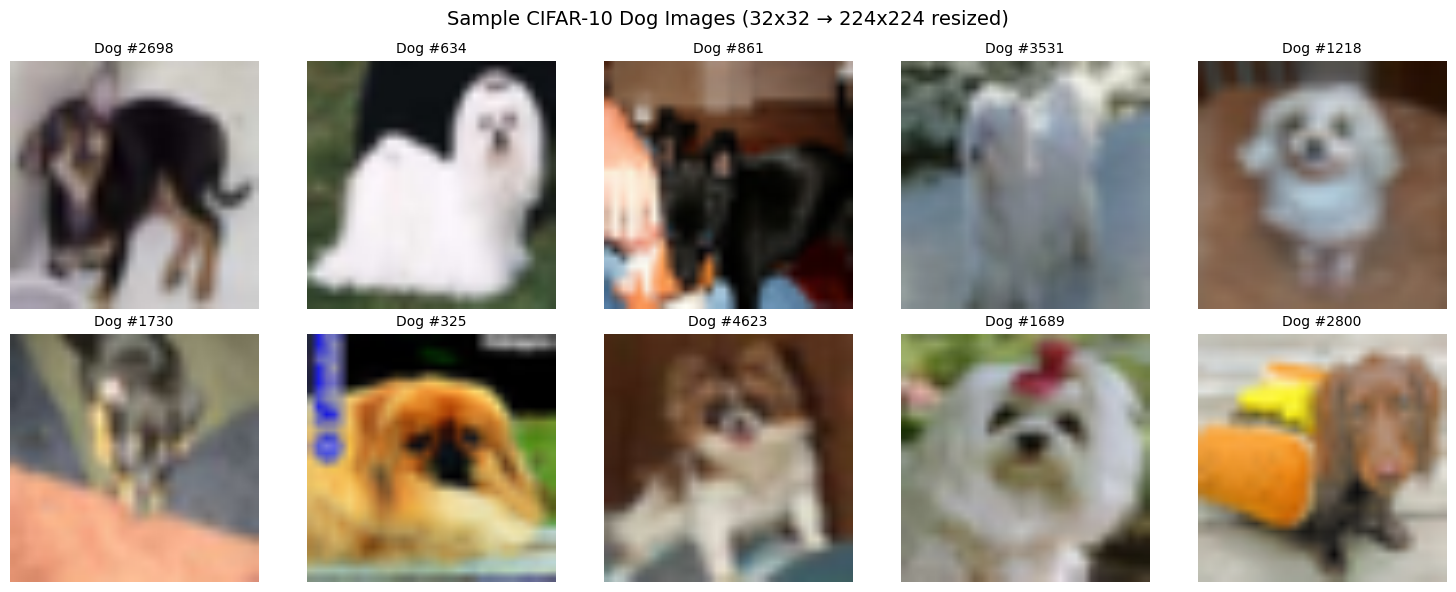

In [ ]:
def show_dog_samples(dataset, num_samples=10):
    """Display sample dog images from the dataset"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        # Get random dog
        idx = np.random.randint(0, len(dataset))
        image, label = dataset[idx]

        # Denormalize for display
        image = image.permute(1, 2, 0).numpy()
        image = (image * 0.5) + 0.5  # Reverse normalization
        image = np.clip(image, 0, 1)  # Keep values in valid range

        axes[i].imshow(image)
        axes[i].set_title(f'Dog #{idx}', fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Sample CIFAR-10 Dog Images (32x32 → 224x224 resized)', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show samples
show_dog_samples(train_dogs)

# Load Pretrained ResNet-18

In [ ]:
# ============================================
# STEP 5: Load Pretrained ResNet-18
# ============================================

# Set device (should show CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet-18
print("Loading ResNet-18 pretrained on ImageNet...")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the last classification layer
# Original ResNet-18: [Conv layers] -> [AdaptiveAvgPool] -> [FC (1000 classes)]
# We want: [Conv layers] -> [AdaptiveAvgPool] -> Output features (512 numbers)
resnet18 = torch.nn.Sequential(*list(resnet18.children())[:-1])

# Set to evaluation mode (no dropout, no batch norm updates)
resnet18.eval()

# Move to GPU
resnet18 = resnet18.to(device)

print(f"\n ResNet-18 loaded and ready!")
print(f"   Model architecture:")
print(f"   - {len(list(resnet18.children()))} layers")
print(f"   - Output: 512 features per image")
print(f"   - Parameters: {sum(p.numel() for p in resnet18.parameters()):,}")

# Test with a dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)
dummy_output = resnet18(dummy_input)
print(f"   - Test output shape: {dummy_output.shape}")
print(f"   (Expected: torch.Size([1, 512, 1, 1]) or [1, 512])")

Using device: cuda
Loading ResNet-18 pretrained on ImageNet...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]



 ResNet-18 loaded and ready!
   Model architecture:
   - 9 layers
   - Output: 512 features per image
   - Parameters: 11,176,512
   - Test output shape: torch.Size([1, 512, 1, 1])
   (Expected: torch.Size([1, 512, 1, 1]) or [1, 512])


In [ ]:
# STEP 5 FIRST: Load the model
# ============================================

import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet-18
print("Loading ResNet-18...")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the last classification layer (keep feature extractor)
resnet18_feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])

# Set to evaluation mode
resnet18_feature_extractor.eval()

# Move to GPU
resnet18_feature_extractor = resnet18_feature_extractor.to(device)

print("ResNet-18 feature extractor ready!")
print(f"   Output shape: 512 features per image")

Using device: cuda
Loading ResNet-18...
ResNet-18 feature extractor ready!
   Output shape: 512 features per image


# Extract Features from Dog Images using ResNet

In [ ]:
# ============================================
# STEP 6 (FIXED): Extract Features from DOGS ONLY
# ============================================


def extract_features(model, dataloader, device, description="Extracting features"):
    """
    Extract feature vectors from all images in a dataloader.
    """
    model.eval()
    features_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=description):
            images = images.to(device)
            batch_features = model(images)
            batch_features = batch_features.view(batch_features.size(0), -1)
            features_list.append(batch_features.cpu().numpy())
            labels_list.append(labels.numpy())

    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return features, labels

print("="*50)
print("Starting Feature Extraction (DOGS ONLY)")
print("="*50)

# IMPORTANT: Use the CORRECT loader names from Step 4
# train_dog_loader, val_dog_loader, test_dog_loader (NOT train_loader!)

# Extract from training dogs
train_features, train_labels = extract_features(
    resnet18_feature_extractor,
    train_dog_loader,  # ← FIXED: Use train_dog_loader
    device,
    "Extracting training dog features"
)

# Extract from validation dogs
val_features, val_labels = extract_features(
    resnet18_feature_extractor,
    val_dog_loader,    # ← FIXED: Use val_dog_loader
    device,
    "Extracting validation dog features"
)

# Extract from test dogs
test_features, test_labels = extract_features(
    resnet18_feature_extractor,
    test_dog_loader,   # ← FIXED: Use test_dog_loader
    device,
    "Extracting test dog features"
)

# Print results
print("\n" + "="*50)
print("Feature Extraction Complete!")
print("="*50)
print(f"📊 Training features: {train_features.shape}")
print(f"   → {train_features.shape[0]} dogs, each with {train_features.shape[1]} features")
print(f"📊 Validation features: {val_features.shape}")
print(f"📊 Test features: {test_features.shape}")

# Verify no NaN or Inf values
print("\n🔍 Checking feature quality:")
print(f"   Any NaN values? {np.isnan(train_features).any()}")
print(f"   Any Inf values? {np.isinf(train_features).any()}")
print(f"   Feature range: [{train_features.min():.3f}, {train_features.max():.3f}]")

# Verify all labels are dogs (class 5)
print(f"\n🐕 Label verification:")
print(f"   Unique labels in training set: {np.unique(train_labels)}")
print(f"   (Should be [5] only!)")

Starting Feature Extraction (DOGS ONLY)


Extracting test dog features: 100%|██████████| 32/32 [00:01<00:00, 16.26it/s]


Feature Extraction Complete!
📊 Training features: (4500, 512)
   → 4500 dogs, each with 512 features
📊 Validation features: (500, 512)
📊 Test features: (1000, 512)

🔍 Checking feature quality:
   Any NaN values? False
   Any Inf values? False
   Feature range: [0.000, 20.514]

🐕 Label verification:
   Unique labels in training set: [5]
   (Should be [5] only!)


## Check if Feature Range is Reasonable

In [ ]:
# Let's check if your features have good variety
print("\n Feature Statistics:")
print(f"   Mean feature value: {train_features.mean():.4f}")
print(f"   Std feature value: {train_features.std():.4f}")
print(f"   % of features that are zero: {(train_features == 0).sum() / train_features.size * 100:.2f}%")

# Check if features are diverse (good for clustering)
feature_variance = train_features.var(axis=0)
print(f"\n Feature diversity:")
print(f"   Average variance across 512 features: {feature_variance.mean():.4f}")
print(f"   Features with zero variance (useless): {(feature_variance == 0).sum()}")


 Feature Statistics:
   Mean feature value: 0.7103
   Std feature value: 0.9422
   % of features that are zero: 4.07%

 Feature diversity:
   Average variance across 512 features: 0.3892
   Features with zero variance (useless): 0


# Discover Dog Breeds with KNN

In [ ]:
# ============================================
# STEP 7: Discover Dog Breeds with K-Means Clustering
# ============================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("="*50)
print("STEP 7: Discovering Dog Breeds")
print("="*50)

# Normalize features (important for clustering)
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

print(f"\n📊 Features normalized!")
print(f"   Mean after normalization: {train_features_scaled.mean():.4f}")
print(f"   Std after normalization: {train_features_scaled.std():.4f}")

# Try different numbers of clusters
# We don't know how many breeds exist in CIFAR-10 dogs, so let's try a range
n_clusters_range = [5, 8, 10, 12, 15, 20]
inertia_scores = []
silhouette_scores = []

from sklearn.metrics import silhouette_score

print(f"\n🔍 Trying different numbers of clusters...")
for k in n_clusters_range:
    print(f"   Testing K={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(train_features_scaled)

    inertia_scores.append(kmeans.inertia_)
    silhouette = silhouette_score(train_features_scaled, clusters)
    silhouette_scores.append(silhouette)
    print(f"Silhouette: {silhouette:.4f}")

# Find best K based on silhouette score
best_k = n_clusters_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ Best number of clusters: K={best_k} (Silhouette: {max(silhouette_scores):.4f})")

# Run final clustering with best K
print(f"\n🎯 Running final clustering with K={best_k}...")
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = final_kmeans.fit_predict(train_features_scaled)
val_clusters = final_kmeans.predict(val_features_scaled)
test_clusters = final_kmeans.predict(test_features_scaled)

print(f"\n📊 Cluster sizes (training set):")
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"   Cluster {cluster_id}: {count} dogs ({count/len(train_clusters)*100:.1f}%)")

STEP 7: Discovering Dog Breeds

📊 Features normalized!
   Mean after normalization: 0.0000
   Std after normalization: 1.0000

🔍 Trying different numbers of clusters...
   Testing K=5... Silhouette: 0.0136
   Testing K=8... Silhouette: 0.0058
   Testing K=10... Silhouette: 0.0062
   Testing K=12... Silhouette: 0.0050
   Testing K=15... Silhouette: -0.0048
   Testing K=20... Silhouette: -0.0044

✅ Best number of clusters: K=5 (Silhouette: 0.0136)

🎯 Running final clustering with K=5...

📊 Cluster sizes (training set):
   Cluster 0: 761 dogs (16.9%)
   Cluster 1: 944 dogs (21.0%)
   Cluster 2: 539 dogs (12.0%)
   Cluster 3: 1355 dogs (30.1%)
   Cluster 4: 901 dogs (20.0%)



🎨 Visualizing discovered breeds...


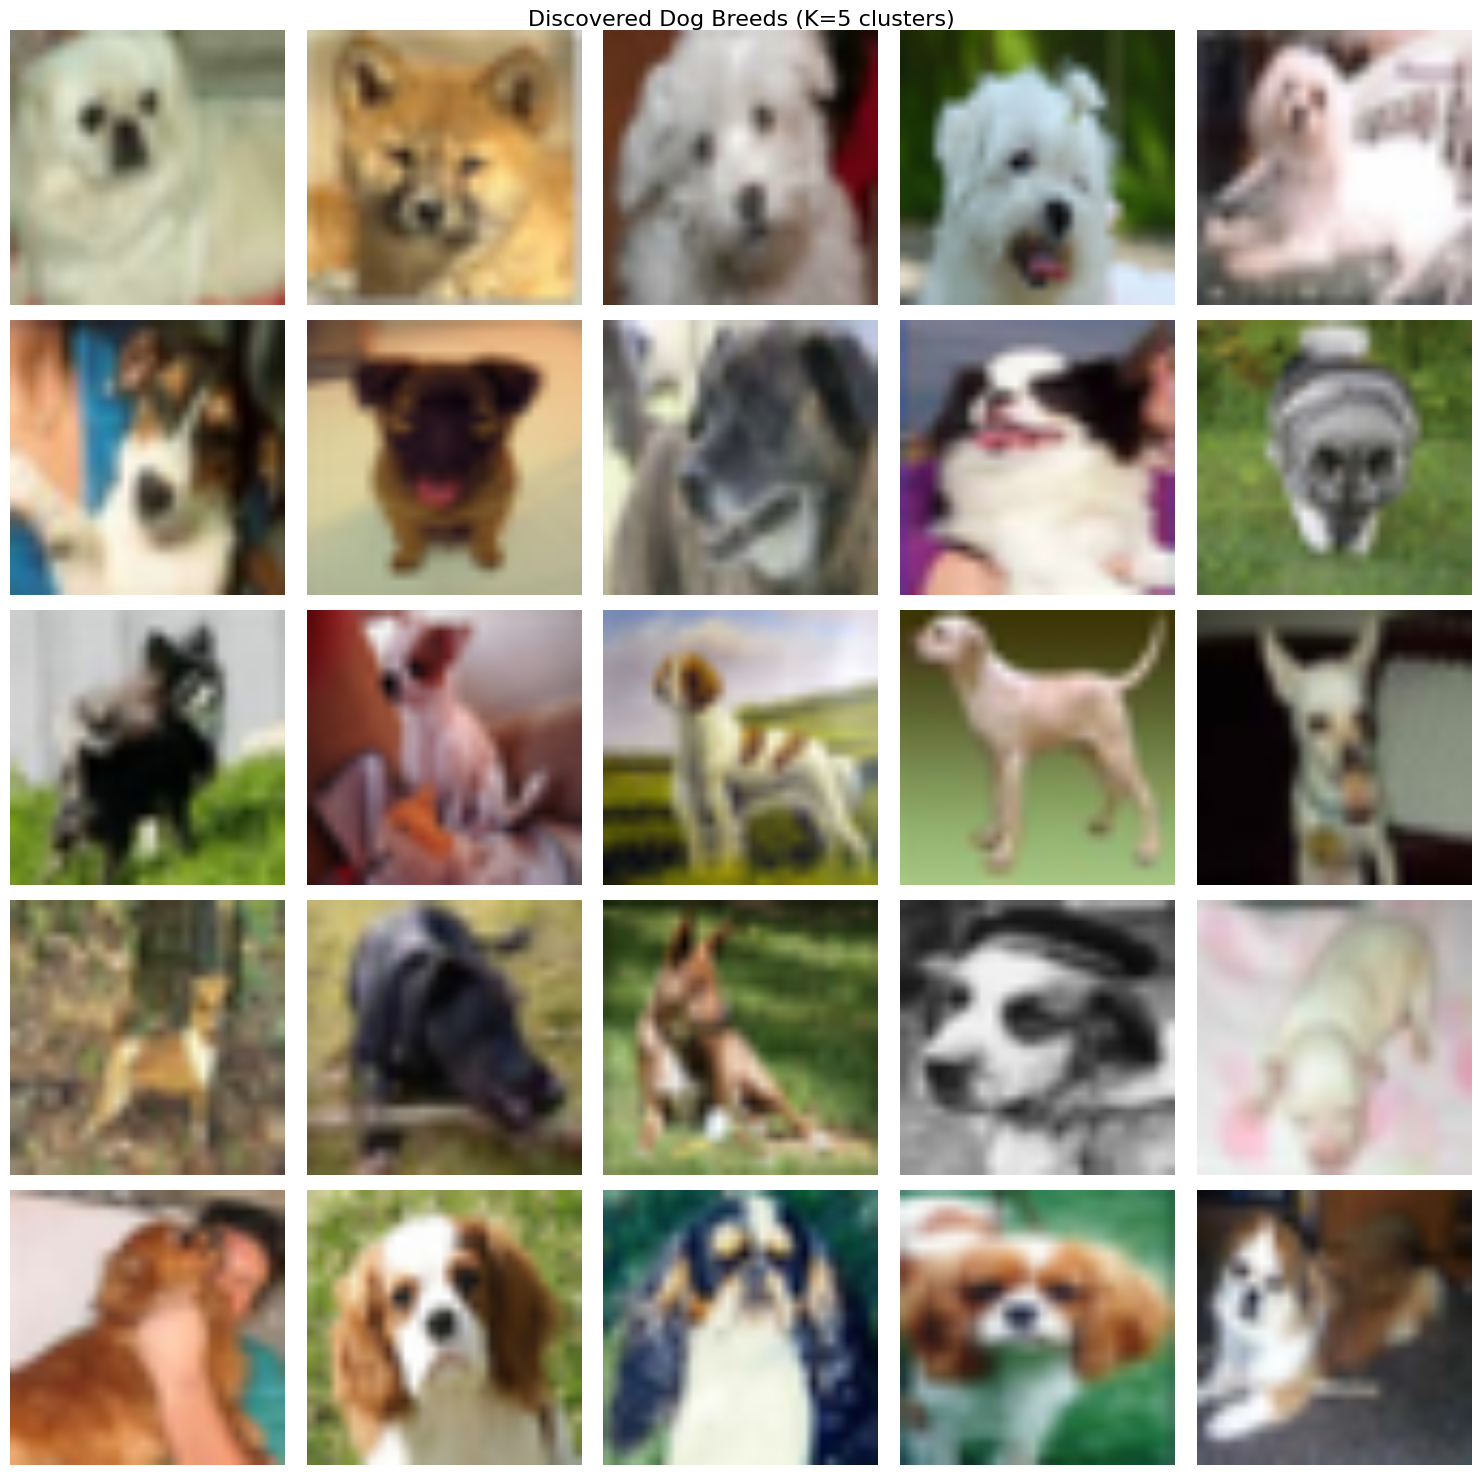

In [ ]:
# ============================================
# STEP 7.5: Visualize Discovered "Breeds"
# ============================================

def visualize_discovered_breeds(dataset, clusters, num_clusters, samples_per_cluster=5):
    """
    Display sample images from each discovered breed (cluster)
    """
    fig, axes = plt.subplots(num_clusters, samples_per_cluster,
                             figsize=(15, 3*num_clusters))

    # Handle case with single cluster
    if num_clusters == 1:
        axes = axes.reshape(1, -1)

    for cluster_id in range(num_clusters):
        # Find indices of dogs in this cluster
        cluster_indices = np.where(clusters == cluster_id)[0]

        if len(cluster_indices) == 0:
            continue

        # Pick random samples
        sample_indices = np.random.choice(
            cluster_indices,
            min(samples_per_cluster, len(cluster_indices)),
            replace=False
        )

        for j, idx in enumerate(sample_indices):
            # Get the image
            image, label = dataset[idx]
            image = image.permute(1, 2, 0).numpy()
            image = (image * 0.5) + 0.5  # Denormalize
            image = np.clip(image, 0, 1)

            axes[cluster_id, j].imshow(image)
            axes[cluster_id, j].axis('off')
            if j == 0:
                axes[cluster_id, j].set_ylabel(f'Breed {cluster_id}',
                                               fontsize=12, rotation=0, labelpad=40)

    plt.suptitle(f'Discovered Dog Breeds (K={num_clusters} clusters)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize your discovered breeds
print("\n🎨 Visualizing discovered breeds...")
visualize_discovered_breeds(train_dog_data, train_clusters, best_k, samples_per_cluster=5)

In [ ]:
# ============================================
# STEP 7.6: Understand Your Discovered Breeds
# ============================================

# For each cluster, show statistics
print("\n" + "="*50)
print("Discovered Breed Analysis")
print("="*50)

for cluster_id in range(best_k):
    cluster_mask = train_clusters == cluster_id
    cluster_size = cluster_mask.sum()

    # Get features for this cluster
    cluster_features = train_features_scaled[cluster_mask]

    # Find average feature vector for this cluster
    avg_features = cluster_features.mean(axis=0)

    # Find most distinctive features (highest values)
    top_features_idx = np.argsort(avg_features)[-5:][::-1]

    print(f"\n🐕 Discovered Breed {cluster_id}:")
    print(f"   Size: {cluster_size} dogs ({cluster_size/len(train_clusters)*100:.1f}%)")
    print(f"   Most distinctive feature indices: {top_features_idx}")

    # Optional: Describe what these features might mean
    print(f"   (Feature values range from {cluster_features.min():.2f} to {cluster_features.max():.2f})")


Discovered Breed Analysis

🐕 Discovered Breed 0:
   Size: 761 dogs (16.9%)
   Most distinctive feature indices: [  0 125 406  31 281]
   (Feature values range from -3.45 to 11.87)

🐕 Discovered Breed 1:
   Size: 944 dogs (21.0%)
   Most distinctive feature indices: [110 293 511 474 386]
   (Feature values range from -3.31 to 14.35)

🐕 Discovered Breed 2:
   Size: 539 dogs (12.0%)
   Most distinctive feature indices: [ 10 398 475 244 316]
   (Feature values range from -3.04 to 15.22)

🐕 Discovered Breed 3:
   Size: 1355 dogs (30.1%)
   Most distinctive feature indices: [255 424  17 202 182]
   (Feature values range from -3.27 to 15.95)

🐕 Discovered Breed 4:
   Size: 901 dogs (20.0%)
   Most distinctive feature indices: [100   1  14 493 127]
   (Feature values range from -3.54 to 14.76)
